# Lecture 13, Notebook 08: Continuous-time Aiyagari — Steady-State PINN (marginal-value form) with an FD benchmark

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance
**Script reference:** Chapter 8, §§8.3–8.5 (HJB, KFE, stationary Aiyagari/Huggett equilibrium) and §8.7 (EMINNs).
**Notebook role:** core
**Author:** Simon Scheidegger and Pavel Ievlev

> This notebook is a faithful, self-contained PyTorch port of the JAX `ss/` soft-penalty solver behind the EMINN Krusell–Smith model (Gu, Laurière, Merkel, Payne, 2024, App. B.1), evaluated at its **deterministic steady state**. There is **no finite-difference solve anywhere in training**: the FD code is the validation reference only. The two neural nets run in float32 (the JAX original's precision); the FD reference is float64 NumPy on CPU.

---

In [1]:
RUN_MODE = "production"  # one of: "smoke", "teaching", "production"
SEED = 0

## A Pedagogical Walkthrough: A Mesh-Free Steady-State PINN, Checked Against Finite Differences

This notebook is designed for teaching. It is intentionally explicit and heavily annotated.

We solve the stationary Aiyagari equilibrium two ways and compare them:

1. **Finite Differences (FD)**, the classic Achdou et al. (2022a) upwind scheme with outer bisection on the interest rate. This is the trusted reference (the "FD gospel"), and nothing it computes ever enters PINN training.
2. **A steady-state PINN**, two small neural nets trained on the HJB and KFE residuals plus a handful of exact integral identities, with **prices and market clearing built in by construction** (no outer bisection).

By the end we compare the marginal value \(W=\partial_a V\), consumption \(c(a,l)\), saving \(s(a,l)\), the stationary density \(g(a,l)\), and the equilibrium aggregates \(K, r, w\), and we score the PINN with a single \(L^\infty\) saving gate against a dense FD policy.

> **In-class notebook** (Chapter 8 / Lecture 13 deck Part II, the in-class mesh-free solver). Full training is about 9 min on CPU at `RUN_MODE="production"`; use `"smoke"` for a fast structural pass that intentionally does **not** clear the gate (the aggregate-saving ramp needs a converged policy, see the failure-modes section).

## Learning Objectives

- Understand the stationary **HJB + KFE + market-clearing** fixed point, written in **marginal-value form** \(W=\partial_a V\).
- See how a PINN can make **market clearing hold by construction**: prices are the firm's marginal products at the density net's *own* aggregates, so there is no outer price loop.
- Learn the role of each loss term, the HJB residual, the KFE (in two forms), and the exact integral identities that close the gaps a pointwise residual leaves open.
- Understand the **continuous Gauss–Seidel** gradient gating (two detachments) that decouples the policy net from the distribution net.
- Diagnose solution quality with residuals, moments, and a saving \(L^\infty\) gate against a dense FD benchmark.

In [2]:
# Standard scientific Python stack
from dataclasses import dataclass
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as Fn
import matplotlib.pyplot as plt

# Reproducibility for classroom consistency (seeds fixed once, here)
torch.manual_seed(SEED)
np.random.seed(SEED)

# We stay on CPU for portability across teaching environments. The two neural
# nets run in float32 (the JAX original's precision); the FD reference is float64
# NumPy. DEV and ONEHOT are module-level constants used throughout, exactly as in
# the single-file ss_torch.py source this notebook is built from.
DEV = "cpu"
device = torch.device(DEV)
ONEHOT = torch.eye(2, device=DEV)
print("Using device:", DEV)
plt.rcParams["font.size"] = 13

Using device: cpu


In [3]:
# Training budget and grid resolution, dispatched on RUN_MODE.
#   - n_iter      : joint-residual training steps (the heavy loop)
#   - n_pretrain  : functional-form pretraining steps
#   - n_a / n_quad: FD reference grid / PINN quadrature grid (resolution-matched)
#   - n_dense     : dense grid for the saving L-infinity gate
# Production reproduces the JAX ss/ recipe (40k iters, 400-pt grids, ~9 min CPU).
if RUN_MODE == "smoke":
    RUN_CFG = dict(n_iter=2_000, n_pretrain=300, n_a=200, n_quad=200, n_dense=400)
elif RUN_MODE == "teaching":
    RUN_CFG = dict(n_iter=12_000, n_pretrain=1_000, n_a=400, n_quad=400, n_dense=1_000)
elif RUN_MODE == "production":
    RUN_CFG = dict(n_iter=40_000, n_pretrain=1_000, n_a=400, n_quad=400, n_dense=1_000)
else:
    raise ValueError(f"Unknown RUN_MODE={RUN_MODE!r}")

# KFE formulation: "fv" (default, conservative finite-volume operator on the
# g-net masses) or "strong" (pure mesh-free autodiff KFE residual). See section 5.
KFE_FORM = "fv"
print(f"RUN_MODE={RUN_MODE}  KFE_FORM={KFE_FORM}  budget={RUN_CFG}")

RUN_MODE=production  KFE_FORM=fv  budget={'n_iter': 40000, 'n_pretrain': 1000, 'n_a': 400, 'n_quad': 400, 'n_dense': 1000}


## Economic Environment and Equilibrium

The EMINN Krusell–Smith model at its **deterministic steady state**: aggregate TFP is pinned at \(z=\bar z\) (no aggregate shocks), so the economy collapses to the classic Aiyagari/Huggett stationary equilibrium.

**Households.** Hold wealth \(a\in[a_{\min},a_{\max}]=[10^{-6},20]\), earn labor income \(w\,l\) with \(l\in\{l_1,l_2\}=\{0.3,1.7\}\) switching by a symmetric Poisson process (\(\lambda_1=\lambda_2=0.4\)), and choose consumption \(c\) with CRRA utility \(u(c)=(c^{1-\gamma}-1)/(1-\gamma)\), \(\gamma=2.1\), discount rate \(\rho=0.05\). The budget is \(\dot a = s = w\,l + r\,a - c\).

**Borrowing constraint (soft form).** Instead of a hard \(a\ge 0\), the flow utility carries the paper's penalty \(\psi(a)=-\tfrac12\kappa(a-a_{lb})^2\) for \(a\le a_{lb}\) (zero above), with \(\kappa=3,\ a_{lb}=1\). Below \(a_{lb}\) the penalty's *gradient* \(\psi'(a)=-\kappa(a-a_{lb})>0\) raises the marginal value of wealth, hence raises saving, so households endogenously avoid the region and the constraint never literally binds.

**Firms / prices.** Cobb–Douglas \(Y=e^z K^\alpha L^{1-\alpha}\) (\(\alpha=1/3\), depreciation \(\delta=0.1\)) with competitive factor markets,
$$
r = \alpha\,e^z (K/L)^{\alpha-1} - \delta,\qquad w=(1-\alpha)\,e^z (K/L)^\alpha.
$$

**Equilibrium** is a triple (policy, distribution, prices) such that the policy is optimal given prices (HJB), the distribution is stationary under that policy (KFE), and prices are the marginal products at the distribution's own aggregates \(K=\sum_j\int a\,g_j\,da\), \(L=\sum_j l_j\int g_j\,da\) (market clearing).

## 1) Calibration and Numerics

The calibration follows the paper's Table 5 at the deterministic steady state (\(z=\bar z=0\)). The numerical hyperparameters follow the JAX `ss/` recipe: two small nets (width 64, depth 4), a fixed 400-point trapezoid quadrature grid for normalization and aggregates, and fresh random collocation each step. Grid sizes and the training length are overridden from `RUN_CFG` so the smoke run stays fast.

In [4]:
@dataclass
class Par:
    alpha: float = 1 / 3; delta: float = 0.1; gamma: float = 2.1; rho: float = 0.05
    z_bar: float = 0.0
    lam1: float = 0.4; lam2: float = 0.4; l1: float = 0.3; l2: float = 1.7
    a_min: float = 1e-6; a_max: float = 20.0; a_lb: float = 1.0; kappa: float = 3.0
    n_quad: int = 400              # quadrature grid: normalization + aggregates + FV KFE
    n_a: int = 400                 # FD reference grid, resolution-matched -- validation ONLY
    width: int = 64; depth: int = 4
    n_col: int = 256               # collocation points per step (each scored at both l)
    frac_focus: float = 0.5; a_focus: float = 6.0    # extra draws near the density peak
    n_pretrain: int = 1000; pretrain_abar: float = 5.0
    n_iter: int = 40_000; lr0: float = 3e-4; lr1: float = 1e-6
    agg_ramp: tuple = (0.2, 0.5)   # aggregate-saving identity ramp (fractions of n_iter)
    n_dense: int = 1000; eps_gate: float = 1e-2      # the shared saving-L^inf gate
    # ---- VARIANT(strong): mesh-free KFE ----
    kfe_form: str = "fv"
    frac_bnd: float = 0.1; a_bnd_top: float = 2.0    # extra collocation band below a_max


# Instantiate with the RUN_MODE grid/length overrides, then set the KFE form.
p = Par(**RUN_CFG)
p.kfe_form = KFE_FORM
print(p)

Par(alpha=0.3333333333333333, delta=0.1, gamma=2.1, rho=0.05, z_bar=0.0, lam1=0.4, lam2=0.4, l1=0.3, l2=1.7, a_min=1e-06, a_max=20.0, a_lb=1.0, kappa=3.0, n_quad=400, n_a=400, width=64, depth=4, n_col=256, frac_focus=0.5, a_focus=6.0, n_pretrain=1000, pretrain_abar=5.0, n_iter=40000, lr0=0.0003, lr1=1e-06, agg_ramp=(0.2, 0.5), n_dense=1000, eps_gate=0.01, kfe_form='fv', frac_bnd=0.1, a_bnd_top=2.0)


## 2) The Equations the Solver Uses

### 2.1 HJB in marginal-value form

The solver never represents \(V\); it works with \(W=\partial_a V\) (as the whole repo does). Starting from the stationary HJB
$$
\rho V = \max_c\; u(c) + \psi(a) + (w\,l + r\,a - c)\,\partial_a V + \lambda_j\,(V_{\text{other}} - V),
$$
the FOC gives \(u'(c)=W\), i.e. \(c=W^{-1/\gamma}\) (this is why \(W>0\) is structural). Differentiating the HJB in \(a\), the \(\partial c/\partial a\) terms cancel by the envelope theorem, leaving the **HJB residual**
$$
0 = (\rho - r + \lambda_j)\,W - s\,\partial_a W - \lambda_j\,W_{\text{other}} - \psi'(a),\qquad s = w\,l_j + r\,a - W^{-1/\gamma}.
$$
All \(z\)-derivative terms and the distribution-coupling term of the full master equation vanish at the deterministic steady state, which is exactly what makes the SS problem self-contained. One extra structural fact used by the strong-form KFE is \(\partial_a s = r - c'(a) = r + (1/\gamma)(c/W)\,\partial_a W\).

### 2.2 Stationary KFE

For each labor state \(j\) (with \(\tilde\jmath\) the other state),
$$
0 = -\partial_a(s_j g_j) + \lambda_{\tilde\jmath} g_{\tilde\jmath} - \lambda_j g_j,\qquad\text{zero flux at } a_{\min}, a_{\max}.
$$
Two exact integral consequences (both used as losses): **labor-mass balance** \(\lambda_1 M_1 = \lambda_2 M_2\) with \(M_j=\int g_j\) (with \(\lambda_1=\lambda_2\) this forces the 50/50 split, hence \(L=1\)), and the **aggregate-saving identity** \(\,dK/dt = \int \sum_j s_j g_j\,da = 0\) (at stationarity the population saves nothing in aggregate).

The code below specializes the CRRA/switching equations of Chapter 8 to this calibration.

In [5]:
def inv_u_prime(W, p):  return W.clamp(min=1e-12) ** (-1.0 / p.gamma)        # c = W^{-1/gamma}
def u_prime(c, p):      return c.clamp(min=1e-12) ** (-p.gamma)              # W = u'(c)

def prices(K, L, p):
    KL = K.clamp(min=1e-8) / L.clamp(min=1e-8)
    z = float(np.exp(p.z_bar))
    return p.alpha * z * KL ** (p.alpha - 1.0) - p.delta, (1.0 - p.alpha) * z * KL ** p.alpha

def soft_penalty_grad(a, p):    # d/da of psi(a) = -1/2 kappa (a-a_lb)^2 for a<=a_lb, else 0
    return torch.where(a <= p.a_lb, -p.kappa * (a - p.a_lb), torch.zeros_like(a))

def kfe_drift(m, s, da, p):
    """Conservative upwind KFE mass drift on the uniform grid (paper eq B.1).  m, s: (n, 2)."""
    sp, sn = s.clamp(min=0.0), s.clamp(max=0.0)
    zero = torch.zeros(1, 2, device=DEV)
    F = sp * m + torch.cat([(sn * m)[1:], zero])               # face flux F_{m+1/2}
    F = torch.cat([F[:-1], zero])                              # zero-flux at a_max
    Da = (F - torch.cat([zero, F[:-1]])) / da                  # bottom face zero too
    lam = torch.tensor([p.lam1, p.lam2], device=DEV)
    return -Da + lam.flip(0) * m.flip(1) - lam * m

## 3) Finite-Difference Reference (validation only)

This is the trusted benchmark, the "FD gospel": a standard Achdou et al. (2022a) upwind scheme on a uniform grid, with **outer bisection on the interest rate** \(r\). Nothing here ever enters PINN training; the FD objects are used only as ground truth for the diagnostics and the saving gate.

- `_fd_inner`: implicit-Euler upwind HJB at fixed prices, then the stationary KFE as the null vector of the generator transpose (one row replaced by the normalization).
- `fd_solve`: bisect \(r\) to clear the capital market (invert the firm FOC for \(K_r\), solve the partial-equilibrium problem, compare with \(K_g=\int a\,g\)).
- `fd_gate`: the dense fixed-price FD saving policy at the FD-equilibrium prices, the reference for the \(L^\infty\) gate. Solving the HJB on the dense grid resolves the kink that interpolating a coarse policy would smear.

The FD reference deliberately uses `n_a = n_quad`, because the FD equilibrium \(K\) is grid-sensitive and the SS solver bakes its own equilibrium into \(W\); gating against a coarser FD would measure discretization mismatch, not solver error.

In [6]:
def _fd_inner(p, a, w, r, max_iter=300, tol=1e-9, dt=1000.0):
    """Implicit-Euler upwind HJB at fixed prices (r, w), then the stationary KFE.  V,g,c,s."""
    n = a.shape[0]
    daf = np.append(np.diff(a), a[-1] - a[-2])
    dab = np.insert(np.diff(a), 0, a[1] - a[0])
    lv = np.array([p.l1, p.l2]); lam = np.array([p.lam1, p.lam2])
    cash = w * lv[None, :] + r * a[:, None]
    psi = np.where(a[:, None] <= p.a_lb, -0.5 * p.kappa * (a[:, None] - p.a_lb) ** 2, 0.0)
    uu = lambda c: (np.clip(c, 1e-12, None) ** (1 - p.gamma) - 1) / (1 - p.gamma)
    V = uu(np.clip(0.5 * cash, 1e-6, None)) / p.rho
    A = np.zeros((2 * n, 2 * n))
    for _ in range(max_iter):
        dV_F = np.vstack([(V[1:] - V[:-1]) / daf[:-1, None], np.zeros((1, 2))])
        dV_B = np.vstack([np.zeros((1, 2)), (V[1:] - V[:-1]) / dab[1:, None]])
        dV_B[0] = np.clip(cash[0], 1e-6, None) ** (-p.gamma)
        dV_F[-1] = np.clip(cash[-1], 1e-6, None) ** (-p.gamma)
        c_F = np.clip(dV_F, 1e-12, None) ** (-1 / p.gamma); c_B = np.clip(dV_B, 1e-12, None) ** (-1 / p.gamma)
        s_F, s_B = cash - c_F, cash - c_B
        uF, uB = s_F > 0, s_B < 0
        c = np.where(uF, c_F, np.where(uB, c_B, cash))
        s = np.where(uF, s_F, np.where(uB, s_B, 0.0))
        sp, sn = np.maximum(s, 0), np.minimum(s, 0)
        A[:] = 0.0
        for j in range(2):
            row = np.arange(n) + j * n
            A[row, row] = -sp[:, j] / daf + sn[:, j] / dab - lam[j]
            A[row[:-1], row[:-1] + 1] = sp[:-1, j] / daf[:-1]
            A[row[1:], row[1:] - 1] = -sn[1:, j] / dab[1:]
            A[row, np.arange(n) + (1 - j) * n] = lam[j]
        rhs = (uu(c) + psi + V / dt).flatten(order="F")
        Vn = np.linalg.solve(np.eye(2 * n) * (p.rho + 1 / dt) - A, rhs).reshape((n, 2), order="F")
        if np.max(np.abs(Vn - V)) < tol:
            V = Vn; break
        V = Vn
    M = A.T.copy(); M[-1] = 1.0
    b = np.zeros(2 * n); b[-1] = 1.0
    g = np.linalg.solve(M, b).reshape((n, 2), order="F")
    g = np.clip(g, 0, None); g = g / g.sum()
    return V, g, c, s


def fd_solve(p):
    """Bisect r to clear the capital market on the uniform n_a grid.  FD equilibrium dict."""
    a = np.linspace(p.a_min, p.a_max, p.n_a)
    L = 0.5 * p.l1 + 0.5 * p.l2
    r_lo, r_hi = -p.delta * 0.5, p.rho * 0.999
    V = g = c = s = None; r = 0.0
    for _ in range(60):
        r = 0.5 * (r_lo + r_hi)
        K_r = ((r + p.delta) / p.alpha) ** (1 / (p.alpha - 1)) * L
        w = (1 - p.alpha) * K_r ** p.alpha * L ** (-p.alpha)
        V, g, c, s = _fd_inner(p, a, w, r, max_iter=200, tol=1e-8)
        K_g = float((a * g.sum(1)).sum())
        if abs(K_g - K_r) < 1e-4:
            break
        r_hi, r_lo = (r, r_lo) if K_g > K_r else (r_hi, r)
    K = float((a * g.sum(1)).sum()); w = (1 - p.alpha) * K ** p.alpha * L ** (-p.alpha)
    return dict(a=a, V=V, g=g, c=c, s=s, K=K, r=float(r), w=float(w), L=float(L))


def fd_gate(p, fd):
    """Dense fixed-price FD saving policy at the FD equilibrium prices -- the L^inf gate ref."""
    ad = np.linspace(p.a_min, p.a_max, p.n_dense)
    s_fd = _fd_inner(p, ad, fd["w"], fd["r"], max_iter=200, tol=1e-8)[3]
    return ad, s_fd, fd["r"], fd["w"]

In [7]:
# Solve the FD reference once. This is the benchmark and the gate target; it does
# NOT enter PINN training. (At n_a=400 this is a few-minute dense linear solve loop;
# the smoke RUN_MODE drops to n_a=200 to stay fast.)
fd = fd_solve(p)
gate = fd_gate(p, fd)
print(f"[FD] K={fd['K']:.4f}  r={fd['r']:.5f}  w={fd['w']:.5f}  L={fd['L']:.4f}")

[FD] K=5.0994  r=0.01251  w=1.14749  L=1.0000


## 4) The Two Neural Nets

Both unknowns are plain MLPs in \((a_{\text{scaled}}, \text{onehot}(l))\): 3 inputs, 4 tanh hidden layers of width 64, a linear head, Glorot/Xavier init, with \(a\) affinely scaled to \([-1,1]\). Float32, seeds fixed at import. `both(net, a)` evaluates the two labor states in one batched forward (`a.repeat(2)` against stacked one-hots, reshaped to \((B,2)\)).

### 4.1 `WNet`, the policy side
$$ W(a,l_j) = \text{softplus}\big(\text{MLP}(a,l_j)\big). $$
Softplus enforces \(W>0\) (marginal utility is positive; \(c=W^{-1/\gamma}\) requires it) and blocks the *parametrization* form of the \(W\to 0\) cheat. But \(W\to 0\) is still an *attractor* the optimizer can approach (\(W\) small \(\Rightarrow c\) huge \(\Rightarrow s\) very negative \(\Rightarrow\) the transport term washes out the HJB residual); what actually guards against it is the pretrain level (§7) and the shape penalty. Audit check D1: the trained net has \(\min W \approx 0.19\), nowhere near the corner, and \(\partial_a W < 0\) everywhere on a fine grid.

### 4.2 `GNet`, the distribution side
$$ f(a,l_j) = \text{MLP}(a,l_j) - \text{softplus}(\beta_j)\,(a-a_{\min}),\qquad g(a,l_j)=\exp\!\big(f(a,l_j)-\log Z\big). $$
Three deliberate choices: **log-space** (positivity for free, and densities spanning 4+ orders of magnitude become \(O(1)\) quantities); a **trainable tail slope \(\beta_j\)** (the true density decays exponentially, but a bounded tanh-MLP cannot steepen its own tail fast enough where the KFE residual is proportional to the tiny local density, so the decay *rate* is made a single parameter per labor state, receiving gradient from every tail node, initialized at the pretrain prior's rate \(1/\bar a\) via the softplus inverse); and **normalization by construction** via `logZ` = logsumexp over (nodes \(\times\) states) on the fixed trapezoid quadrature, so \(\sum_j\int g = 1\) identically (audit D2: total mass = 1.0000), removing the KFE's scale invariance without a tradeable penalty.

### 4.3 Prices by construction
Every loss evaluation recomputes, from the g-net's current weights, \(f_q\to\log Z\to g_q\to K=\sum a\,w_q\,g,\ L=\sum l\,w_q\,g\to r,w\). There is **no stored price variable and no outer bisection**: market clearing holds identically at every step because \(r,w\) are defined as marginal products at the g-net's own aggregates. The classical nested algorithm (solve a full partial-equilibrium problem per candidate \(r\), then bisect, as `fd_solve` does) is replaced by one flat loop in which the distribution shifting *is* the price adjustment. This relies on the Aiyagari fixed point being stable (\(K\) too high \(\Rightarrow r\) low \(\Rightarrow\) saving down \(\Rightarrow\) mass flows down \(\Rightarrow K\) falls); an unstable GE feedback would break the joint scheme.

In [8]:
class MLP(nn.Module):
    def __init__(self, p):
        super().__init__()
        dims = [3] + [p.width] * p.depth + [1]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers); self.p = p
        for m in self.net:                                     # Glorot init (as in the JAX nets)
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, a, oh):
        """a (B,), oh (B,2) -> (B,).  Wealth scaled to [-1, 1]."""
        p = self.p
        a_n = (2 * (a - p.a_min) / (p.a_max - p.a_min) - 1).unsqueeze(-1)
        return self.net(torch.cat([a_n, oh], -1)).squeeze(-1)


class WNet(nn.Module):
    """Marginal value W = d_a V > 0 (softplus output)."""
    def __init__(self, p):
        super().__init__(); self.mlp = MLP(p)

    def forward(self, a, oh):
        return Fn.softplus(self.mlp(a, oh))


class GNet(nn.Module):
    """Raw log-density f: MLP modulation on a TRAINABLE log-linear tail slope.  The true
    stationary density decays ~exponentially; a plain tanh-MLP in log space cannot steepen its
    own tail fast enough, so the decay rate is an explicit parameter per labor state."""
    def __init__(self, p):
        super().__init__(); self.mlp = MLP(p); self.p = p
        slope0 = float(np.log(np.expm1(1.0 / p.pretrain_abar)))     # softplus^{-1}(1/abar)
        self.beta = nn.Parameter(torch.full((2,), slope0))

    def forward(self, a, oh):
        return self.mlp(a, oh) - (oh @ Fn.softplus(self.beta)) * (a - self.p.a_min)


def both(net, a):
    """Evaluate net at (a, l_j) for both labor states in one forward.  a (B,) -> (B, 2)."""
    B = a.shape[0]
    return net(a.repeat(2), ONEHOT.repeat_interleave(B, 0)).view(2, B).T


def quad_rule(p):
    """Uniform quadrature grid + trapezoid weights on [a_min, a_max]."""
    a_q = torch.linspace(p.a_min, p.a_max, p.n_quad, device=DEV)
    da = float(a_q[1] - a_q[0])
    w_q = torch.full((p.n_quad,), da, device=DEV); w_q[0] = w_q[-1] = 0.5 * da
    return a_q, w_q, da


@torch.no_grad()
def nn_equilibrium(netg, p):
    """The PINN's own equilibrium: logZ, density, aggregates, prices from the g-net quadrature."""
    a_q, w_q, _ = quad_rule(p)
    f_q = both(netg, a_q)
    logZ = torch.logsumexp((f_q + w_q.log().unsqueeze(-1)).reshape(-1), 0)
    mass = w_q.unsqueeze(-1) * torch.exp(f_q - logZ)
    K = (a_q.unsqueeze(-1) * mass).sum()
    L = (torch.tensor([p.l1, p.l2], device=DEV) * mass).sum()
    r, w = prices(K, L, p)
    return float(K), float(L), float(r), float(w), logZ

## 5) The Joint Loss, Term by Term

`make_loss(p)` builds a closure over the quadrature grid. Each call computes:

**HJB residual** (trains the W-net) at `n_col=256` fresh random collocation points, both labor states. \(\partial_a W\) is taken by **exact autograd**: the batch is `a.repeat(2)` with `requires_grad`, one forward, one `torch.autograd.grad(W.sum(), a, create_graph=True)`. The `.sum()` trick is valid because the Jacobian is diagonal (each output depends only on its own input), and `create_graph=True` makes the derivative itself differentiable so the loss can train through it. The policy inside is *live* (the net is asked to satisfy its own FOC-consistent equation); prices are *detached*. This term is fully mesh-free in both KFE modes.

**Shape penalty** \(L_{\text{shape}}=\text{mean}[\max(\partial_a W,0)^2]\): the monotonicity prior \(V\) concave. It costs nothing once satisfied (it reads 0.0 after warm-up) but blocks sign-flipped or oscillating \(W\) during the transient, and is one of the two guards against the \(W\to 0\) corner.

**KFE, form "fv" (default)**: the paper's conservative upwind finite-volume operator (`kfe_drift`) applied to the g-net masses on the quadrature grid. This is **not an FD solve**: no generator is assembled and no linear system is solved; `kfe_drift` is an algebraic map (shifts, clamps, multiplies) from the net's values to the rate at which mass would flow, and the gradient flows through the masses into the g-net. Because it is conservative/upwind, total mass is conserved for any policy, the zero-flux BCs are built in, and the strong form's structural cheats are impossible by construction. The `μ/da` scaling makes the residual a density-rate, so the loss magnitude is grid-resolution-independent, and the operator equals the FD generator \(A^\top\) to ~3e-10 (the FD solver enters only as the validation reference; scrambling it leaves training bit-identical).

**KFE, form "strong"**: pure mesh-free, the KFE enforced by exact autodiff at the collocation points, with the policy pair \((s,\partial_a s)\) detached. Here *mesh-free* means precisely that the PDE is enforced by exact autodiff at sampled points; the integral identities may still be evaluated by quadrature of net *values* (normalization already requires that), which involves no stencils. The pointwise residual alone is not well posed, so three exact identities close the gaps, each killing a failure mode diagnosed in the JAX runs:

1. **Pointwise total-flux identity** \(\sum_j s_j g_j = 0\). Summing the two KFE equations cancels the jump terms, so the strong residual only forces \(\partial_a(\text{total flux})=0\); total flux = any nonzero constant has zero residual, the family \(g\sim 1/|s|\) (JAX run 1 found exactly this: \(K\) drifted to ~11, \(r<0\), near-zero KFE loss). Forcing the flux to 0 pointwise excludes it (\(F_1=-F_2=\text{const}\neq 0\) would force \(\lambda_1 g_1=\lambda_2 g_2\) *and* \(s_1 g_1=-s_2 g_2\) pointwise, hence generically \(g=0\)). In fv form the boundary faces are hard-zero, so this is impossible.
2. **Labor-mass balance** \(\lambda_1 M_1=\lambda_2 M_2\). An MSE-imperfect pointwise residual does not pin the labor split (JAX run 3 settled at \(L\approx 0.3\), \(r\approx -0.05\), a pseudo-equilibrium). In fv form the balance telescopes exactly inside the operator.

Plus **zero-flux endpoint penalties** \(L_{\text{bc}}\) (the BCs the fv operator gets for free) and an extra **top collocation band** over the employed's \(s\approx 0\) weak-transport zone, where the transport term \(s\,\partial_a g\) barely transmits information so the region needs explicit sampling density.

**Aggregate-saving identity** (both forms, ramped) \(L_{\text{agg}}=(\sum_{\text{nodes},j} w_q\,s_j\,g_j)^2\): the first moment of the stationary KFE (\(dK/dt=0\)). The pointwise KFE MSE plateaus at a floor (~1.4e-7 in the JAX fv runs) below which a 10×-overweight tail, worth +0.2 on \(K\) through the \(a\approx 15\) lever arm, hides; the identity is exactly the \(K\)-relevant functional the pointwise residual barely sees, and its gradient \(\propto s_i\) moves mass from dissaving regions toward savers (surgical, unlike tail-reweighting the MSE). It is **ramped** (weight 0 until 20% of `n_iter`, linear to full at 50%) because switched on from step 0 it acts on the garbage pretrain policy and crushes all mass to the bottom (\(K\) locks at ~1.2–1.4). This is not folklore: both of this port's `n_iter=1000` smoke runs reproduced the crush exactly. By ~20% of training the policy is sane (HJB ~1e-3) and the identity is purely stabilizing.

$$ \text{total} = L_{\text{hjb}} + L_{\text{kfe}} + L_{\text{flux}} + \text{agg\_w}\cdot L_{\text{agg}} + L_{\text{mass}} + L_{\text{bc}} + L_{\text{shape}}, $$
with all weights 1 (the ramp factor is the only schedule) and, in fv mode, \(L_{\text{flux}}=L_{\text{mass}}=L_{\text{bc}}=0\) identically.

In [9]:
def make_loss(p):
    a_q, w_q, da = quad_rule(p)
    lam = torch.tensor([p.lam1, p.lam2], device=DEV)
    l_vec = torch.tensor([p.l1, p.l2], device=DEV)
    logw = w_q.log().unsqueeze(-1)

    def loss_fn(netW, netg, a_col, agg_w):
        # distribution side: normalization + aggregates -> prices (clearing by construction)
        f_q = both(netg, a_q)
        logZ = torch.logsumexp((f_q + logw).reshape(-1), 0)
        g_q = torch.exp(f_q - logZ)                              # (n_quad, 2) live density
        mass = w_q.unsqueeze(-1) * g_q
        K = (a_q.unsqueeze(-1) * mass).sum()
        L = (l_vec * mass).sum()
        r, w = prices(K, L, p)
        r, w = r.detach(), w.detach()       # frozen prices: the g-net cannot bend K for the HJB

        # HJB at the collocation points (exact autodiff, live policy, both labor states):
        #   0 = (rho - r + lam_j) W - s d_aW - lam_j W_other - psi'(a),  s = w l_j + r a - W^{-1/gamma}
        B = a_col.shape[0]
        a2 = a_col.repeat(2).requires_grad_(True)
        W2 = netW(a2, ONEHOT.repeat_interleave(B, 0))
        dWa2 = torch.autograd.grad(W2.sum(), a2, create_graph=True)[0]
        W, dWa = W2.view(2, B).T, dWa2.view(2, B).T              # (B, 2) each
        s = w * l_vec + r * a_col.unsqueeze(-1) - inv_u_prime(W, p)
        res = ((p.rho - r + lam) * W - s * dWa - lam * W.flip(1)
               - soft_penalty_grad(a_col, p).unsqueeze(-1))
        L_hjb = res.pow(2).mean()
        L_shape = dWa.clamp(min=0).pow(2).mean()                 # paper's shape penalty d_aW <= 0

        # KFE (either form): the policy is detached (given drift), so the W-net cannot bend
        # the policy to flatter the KFE residual
        with torch.no_grad():
            s_q = w * l_vec + r * a_q.unsqueeze(-1) - inv_u_prime(both(netW, a_q), p)
        # aggregate-saving identity int sum_j s_j g_j da = 0 (first moment; pins K), ramped
        L_agg = (w_q.unsqueeze(-1) * s_q * g_q).sum() ** 2

        if p.kfe_form == "fv":
            # conservative FV operator on the g-net masses (paper eq B.1)
            mu = kfe_drift(g_q * da, s_q, da, p)
            L_kfe = (mu / da).pow(2).mean()
            L_flux = L_mass = L_bc = torch.zeros((), device=DEV)  # built into the operator
        else:
            # VARIANT(strong) -- PURE MESH-FREE: autodiff residual at the collocation points
            #   0 = -(s d_a g + g d_a s) + lam_{j~} g_{j~} - lam_j g_j,   d_a g = g d_a f
            # with the policy (s, d_a s) detached; d_a s = r + (1/gamma)(c/W) d_aW
            a3 = a_col.repeat(2).requires_grad_(True)
            f2 = netg(a3, ONEHOT.repeat_interleave(B, 0))
            dfa = torch.autograd.grad(f2.sum(), a3, create_graph=True)[0]
            f_c, dfa = f2.view(2, B).T, dfa.view(2, B).T
            g_c = torch.exp(f_c - logZ)                          # (B, 2) live density
            c_col = inv_u_prime(W, p)                            # W live, from the HJB block
            s_c = (w * l_vec + r * a_col.unsqueeze(-1) - c_col).detach()
            dsa = (r + (1.0 / p.gamma) * (c_col / W) * dWa).detach()
            kfe = -(s_c * g_c * dfa + g_c * dsa) + lam.flip(0) * g_c.flip(1) - lam * g_c
            L_kfe = kfe.pow(2).mean()
            # (i) pointwise total-flux identity sum_j s_j g_j = 0: kills the const-flux cheat
            # family g ~ 1/|s| (the strong residual only forces d_a(total flux) = 0)
            L_flux = (s_c * g_c).sum(1).pow(2).mean()
            # (ii) labor-mass balance lam_1 M_1 = lam_2 M_2 (KFE integrated over a): nothing
            # pointwise pins the split under imperfect MSE
            M = mass.sum(0)
            L_mass = (lam[0] * M[0] - lam[1] * M[1]) ** 2
            # zero-flux boundary penalties s*g = 0 at a_min, a_max (policy detached)
            a_e = torch.tensor([p.a_min, p.a_max], device=DEV)
            with torch.no_grad():
                s_e = w * l_vec + r * a_e.unsqueeze(-1) - inv_u_prime(both(netW, a_e), p)
            g_e = torch.exp(both(netg, a_e) - logZ)
            L_bc = (s_e * g_e).pow(2).sum()

        total = L_hjb + L_kfe + L_flux + agg_w * L_agg + L_mass + L_bc + L_shape
        aux = dict(hjb=L_hjb.item(), kfe=L_kfe.item(), flux=L_flux.item(), agg=L_agg.item(),
                   mass=L_mass.item(), bc=L_bc.item(), shape=L_shape.item(),
                   K=K.item(), r=float(r))
        return total, aux
    return loss_fn


def draw_collocation(p):
    """Uniform on [a_min, a_max] plus a focus band near the constraint/density peak;
    VARIANT(strong): a top band over the employed's s ~ 0 weak-transport zone."""
    n_f = int(p.n_col * p.frac_focus)
    n_t = int(p.n_col * p.frac_bnd) if p.kfe_form == "strong" else 0
    parts = [torch.empty(p.n_col - n_f - n_t, device=DEV).uniform_(p.a_min, p.a_max),
             torch.empty(n_f, device=DEV).uniform_(p.a_min, p.a_focus)]
    if n_t:
        parts.append(torch.empty(n_t, device=DEV).uniform_(p.a_max - p.a_bnd_top, p.a_max))
    return torch.cat(parts)

## 6) Gradient Gating: the Continuous Gauss–Seidel

There is **one joint loss, one backward pass, one Adam step over both nets** simultaneously, no alternation. The Gauss–Seidel character comes from exactly two detachments:

- \(r,w\) are **detached** right after computation, so \(\partial L_{\text{hjb}}/\partial(\text{g-net})=0\). The g-net cannot bend aggregates/prices to flatter the HJB residual; the W-net solves "the HJB at the current prices."
- the policy values (\(s_q\) on the grid; \(s,\partial_a s\) at collocation in strong mode) are **detached** in every g-side term, so \(\partial(L_{\text{kfe}}+L_{\text{flux}}+L_{\text{agg}}+L_{\text{bc}})/\partial(\text{W-net})=0\). The W-net cannot bend the policy to flatter the KFE; the g-net solves "the KFE under the current policy."

Each net descends only its own equation given the other's current values, a continuous Gauss–Seidel iteration on the Aiyagari fixed point, which converges because that fixed point is economically stable. The HJB's own policy stays *live*, that is the net's optimality condition, not a coupling channel.

Audit Test E verified that both cross-gradients are exactly 0.0 at the trained point.

## 7) Training Pipeline

**Pre-training** (model-implied targets, never FD): \(f\to -a/\bar a\) (a generic decreasing exponential with prior capital \(K_0\approx 4.63\)) and \(W\to u'(w_0 l + r_0 a)\) (the marginal value of the *zero-saving* policy at the prices implied by the pretrain density's own \((K_0, L_0=1)\)). The level matters: the HJB near \(a_{\min}\) must cancel \(\psi'(a_{\min})\approx \kappa a_{lb}=3\) against \((\rho - r + \lambda)W\approx 0.3\,W\), which needs \(W(a_{\min},l_1)\approx u'(w_0 l_1)\approx 10\). Both nets are warm-started to equal quality so neither overfits the other's noise. Pretraining is deliberately crude; residual training does all the work.

**Collocation sampling** (fresh every step): 50% uniform on \([a_{\min},a_{\max}]\), 50% uniform on \([a_{\min},6]\) (the focus band over the constraint and density peak), and in strong mode an extra 10% over \([a_{\max}-2,a_{\max}]\). The quadrature grid is fixed; sampling never moves it.

**Optimization**: a single Adam over both nets, LR linearly decayed \(3\times10^{-4}\to 10^{-6}\), the agg-identity ramp over `[0.2, 0.5] * n_iter`. Every `n_iter/20` steps the loss components and the validation gate are logged (the gate is a cheap no-grad forward and consumes no RNG, so monitoring cannot perturb training).

Pretraining is deliberately crude: the post-pretrain gate metric is ~44.5, and residual training does all the work (44.5 \(\to\) 3.9e-3). Full training is about 9 min on CPU in fv mode, ~13 min in strong (the extra autodiff through the g-net).

In [10]:
@torch.no_grad()
def saving_linf(netW, p, gate):
    """|| s_NN - s_FD ||_inf on the dense grid at matched FD-equilibrium prices."""
    ad, s_fd, r, w = gate
    a = torch.tensor(ad, dtype=torch.float32, device=DEV)
    c = inv_u_prime(both(netW, a), p).cpu().numpy()
    s = w * np.array([p.l1, p.l2])[None] + r * ad[:, None] - c
    return float(np.max(np.abs(s - s_fd)))


def train(p, gate):
    netW, netg = WNet(p).to(DEV), GNet(p).to(DEV)
    params = list(netW.parameters()) + list(netg.parameters())
    l_vec = torch.tensor([p.l1, p.l2], device=DEV)

    # pre-train BOTH nets to model-implied generic targets (never FD): f -> -a/abar, and
    # W -> u'(w0 l + r0 a), the ZERO-SAVING marginal value at the pretrain density's own prices
    a_q, w_q, _ = quad_rule(p)
    dens = torch.exp(-a_q / p.pretrain_abar); dens = dens / (dens * w_q).sum()
    K0 = (a_q * dens * w_q).sum(); L0 = torch.tensor(0.5 * (p.l1 + p.l2), device=DEV)
    r0, w0 = prices(K0, L0, p)
    opt = torch.optim.Adam(params, lr=p.lr0)
    for it in range(p.n_pretrain):
        a = draw_collocation(p)
        W_tg = u_prime(w0 * l_vec + r0 * a.unsqueeze(-1), p)
        loss = (((both(netW, a) - W_tg) ** 2).sum(1).mean()
                + ((both(netg, a) + (a / p.pretrain_abar).unsqueeze(-1)) ** 2).sum(1).mean())
        opt.zero_grad(); loss.backward(); opt.step()
        if it % max(1, p.n_pretrain // 5) == 0:
            print(f"[pretrain {it}] loss={loss.item():.3e}")

    # joint residual training (Adam, linear LR decay, ramped aggregate identity)
    loss_fn = make_loss(p)
    opt = torch.optim.Adam(params, lr=p.lr0)
    ramp0, ramp1 = p.agg_ramp
    log = []
    for it in range(p.n_iter):
        for grp in opt.param_groups:
            grp["lr"] = p.lr0 + (p.lr1 - p.lr0) * it / p.n_iter
        frac = it / p.n_iter
        agg_w = min(1.0, max(0.0, (frac - ramp0) / max(ramp1 - ramp0, 1e-9)))
        loss, aux = loss_fn(netW, netg, draw_collocation(p), agg_w)
        opt.zero_grad(); loss.backward(); opt.step()
        if it % max(1, p.n_iter // 20) == 0 or it == p.n_iter - 1:
            sv = saving_linf(netW, p, gate)
            log.append(dict(it=it, total=loss.item(), sv=sv, **aux))
            print(f"[{it:5d}] loss={loss.item():.4e}  hjb={aux['hjb']:.3e}  "
                  f"kfe={aux['kfe']:.3e}  flux={aux['flux']:.2e}  agg={aux['agg']:.2e}  "
                  f"mass={aux['mass']:.2e}  bc={aux['bc']:.2e}  shape={aux['shape']:.2e}  "
                  f"K={aux['K']:.3f}  |s-sFD|inf={sv:.3e}")
    return netW, netg, log

In [11]:
# Joint PINN training: functional-form pretrain, then joint residual descent.
# Progress lines print the loss components, the g-net's aggregate K, and the
# running saving L-infinity gate. (~9 min CPU at production; smoke is ~30 s.)
netW, netg, log = train(p, gate)

[pretrain 0] loss=3.039e+01


[pretrain 200] loss=8.783e-01


[pretrain 400] loss=1.519e-01


[pretrain 600] loss=4.542e-02


[pretrain 800] loss=4.071e-02


...

[32000] loss=3.3066e-05  hjb=3.220e-05  kfe=8.480e-08  flux=0.00e+00  agg=7.78e-07  mass=0.00e+00  bc=0.00e+00  shape=0.00e+00  K=5.076  |s-sFD|inf=6.289e-03


[34000] loss=9.4734e-06  hjb=9.374e-06  kfe=7.970e-08  flux=0.00e+00  agg=1.93e-08  mass=0.00e+00  bc=0.00e+00  shape=0.00e+00  K=5.074  |s-sFD|inf=5.084e-03


[36000] loss=9.3061e-06  hjb=9.200e-06  kfe=7.515e-08  flux=0.00e+00  agg=3.12e-08  mass=0.00e+00  bc=0.00e+00  shape=0.00e+00  K=5.070  |s-sFD|inf=3.807e-03


[38000] loss=1.5272e-05  hjb=1.520e-05  kfe=7.165e-08  flux=0.00e+00  agg=3.49e-09  mass=0.00e+00  bc=0.00e+00  shape=0.00e+00  K=5.072  |s-sFD|inf=4.078e-03


[39999] loss=8.1906e-06  hjb=8.120e-06  kfe=7.018e-08  flux=0.00e+00  agg=2.16e-10  mass=0.00e+00  bc=0.00e+00  shape=0.00e+00  K=5.071  |s-sFD|inf=3.944e-03


## 8) Diagnostics: FD vs PINN

The first dashboard overlays the PINN solution on the FD reference for the marginal value \(W\), consumption \(c\), saving \(s\) (evaluated at the matched FD-equilibrium prices, the gate convention), and the stationary density \(g\), and shows the joint loss and the running \(L^\infty\) saving gate. The PINN is never trained on these FD arrays; they are ground truth for comparison only.

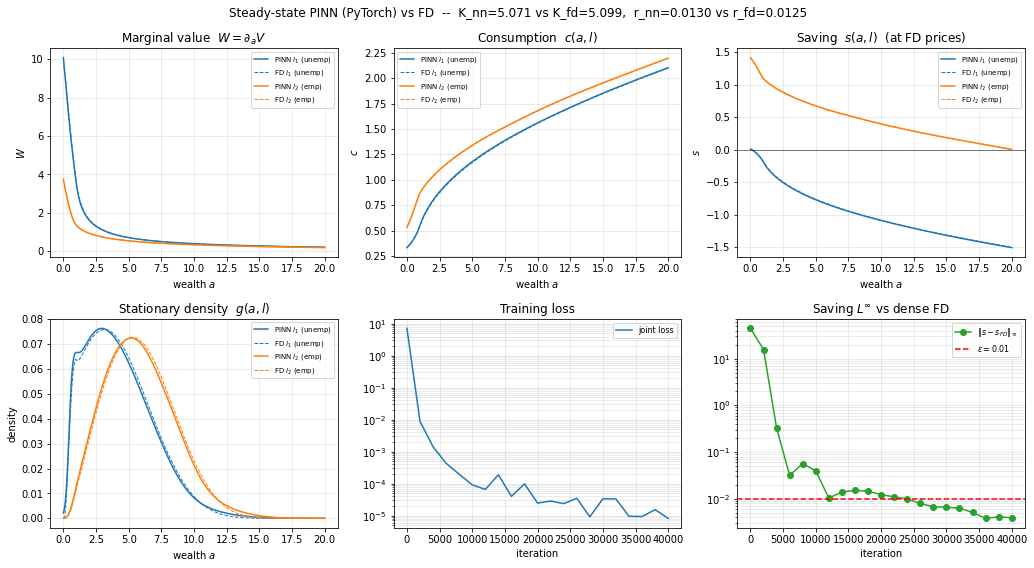

In [12]:
# === FD vs PINN: policies, density, and training diagnostics ===
a = fd["a"]
at = torch.tensor(a, dtype=torch.float32, device=DEV)
K_nn, L_nn, r_nn, w_nn, logZ = nn_equilibrium(netg, p)
with torch.no_grad():
    W = both(netW, at)
    c = inv_u_prime(W, p).cpu().numpy()
    dens_nn = torch.exp(both(netg, at) - logZ).cpu().numpy()
    W = W.cpu().numpy()
# NN saving at the matched FD-equilibrium prices (c_NN = W^{-1/gamma} is price-free)
s = fd["w"] * np.array([p.l1, p.l2])[None] + fd["r"] * a[:, None] - c
W_fd = np.clip(fd["c"], 1e-12, None) ** (-p.gamma)
dens_fd = fd["g"] / (a[1] - a[0])                                       # mass -> density

fig, ax = plt.subplots(2, 3, figsize=(14.5, 8))
lab = ["$l_1$ (unemp)", "$l_2$ (emp)"]

def overlay(axis, nn_, fd_, title, ylab):
    for l in range(2):
        axis.plot(a, nn_[:, l], f"C{l}", label=f"PINN {lab[l]}")
        axis.plot(a, fd_[:, l], f"C{l}", ls="--", lw=1, label=f"FD {lab[l]}")
    axis.set(title=title, xlabel="wealth $a$", ylabel=ylab); axis.legend(fontsize=7); axis.grid(alpha=0.3)

overlay(ax[0, 0], W, W_fd, "Marginal value  $W=\\partial_a V$", "$W$")
overlay(ax[0, 1], c, fd["c"], "Consumption  $c(a,l)$", "$c$")
overlay(ax[0, 2], s, fd["s"], "Saving  $s(a,l)$  (at FD prices)", "$s$"); ax[0, 2].axhline(0, color="k", lw=0.5)
overlay(ax[1, 0], dens_nn, dens_fd, "Stationary density  $g(a,l)$", "density")

its   = [d["it"] for d in log]
total = [d["total"] for d in log]
sv    = [d["sv"] for d in log]
ax[1, 1].semilogy(its, total, label="joint loss"); ax[1, 1].set(title="Training loss", xlabel="iteration")
ax[1, 1].legend(fontsize=8); ax[1, 1].grid(alpha=0.3, which="both")
ax[1, 2].semilogy(its, sv, "o-", color="C2", label=r"$\|s-s_{FD}\|_\infty$")
ax[1, 2].axhline(p.eps_gate, color="r", ls="--", label=rf"$\epsilon={p.eps_gate}$")
ax[1, 2].set(title=r"Saving $L^\infty$ vs dense FD", xlabel="iteration")
ax[1, 2].legend(fontsize=8); ax[1, 2].grid(alpha=0.3, which="both")

fig.suptitle(f"Steady-state PINN (PyTorch) vs FD  --  K_nn={K_nn:.3f} vs K_fd={fd['K']:.3f},  "
             f"r_nn={r_nn:.4f} vs r_fd={fd['r']:.4f}", fontsize=12)
fig.tight_layout(); plt.show()

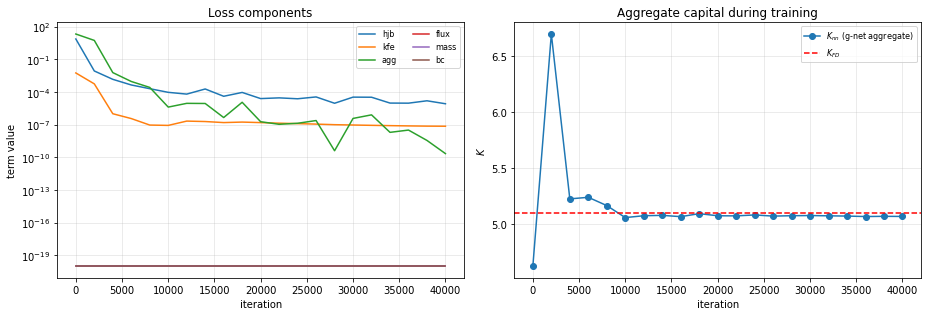

In [13]:
# === PINN training: loss-component breakdown and the K trajectory ===
its = [d["it"] for d in log]
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
for key in ["hjb", "kfe", "agg", "flux", "mass", "bc"]:
    ys = [max(d[key], 1e-20) for d in log]
    ax[0].semilogy(its, ys, label=key)
ax[0].set(title="Loss components", xlabel="iteration", ylabel="term value")
ax[0].legend(fontsize=8, ncol=2); ax[0].grid(alpha=0.3, which="both")
Ks = [d["K"] for d in log]
ax[1].plot(its, Ks, "o-", label=r"$K_{nn}$ (g-net aggregate)")
ax[1].axhline(fd["K"], color="r", ls="--", label=r"$K_{FD}$")
ax[1].set(title="Aggregate capital during training", xlabel="iteration", ylabel="$K$")
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
fig.tight_layout(); plt.show()

## 9) The Saving \(L^\infty\) Gate

The gate is \(\lVert s_{\text{NN}} - s_{\text{FD}}\rVert_\infty\) on a dense grid at matched FD-equilibrium prices, with \(s_{\text{NN}} = w_{\text{fd}}\,l + r_{\text{fd}}\,a - c_{\text{NN}}\). Since \(c_{\text{NN}} = W^{-1/\gamma}\) does not depend on prices, passing requires *both* the right policy shape and the right equilibrium: if \(r_{\text{nn}}\neq r_{\text{fd}}\) the W-net solved a different problem and the comparison blows up. The pass threshold is \(\epsilon=10^{-2}\).

A full `production` run clears the gate (the JAX recipe reports `fv` ~3.9e-3, `strong` ~8.2e-3, with \(K_{\text{nn}}\approx 5.07\) against \(K_{\text{fd}}\approx 5.10\)). The `smoke` run will report **FAIL** by design: the aggregate-saving ramp engages while the policy is still unconverged, so it does not reach the threshold in 2000 steps.

Resolution matching matters: the FD equilibrium \(K\) is grid-sensitive (5.27 at 93 points, 5.10 at 400, 5.07 at 800), so the reference deliberately uses `n_a = n_quad`. Notably the trained \(K_{\text{nn}}=5.0706\) lands on FD(800) = 5.0730, closer to the continuum than its own 400-point reference: the mesh-free HJB side pulls the equilibrium toward the continuum solution.

In [14]:
# === The shared saving-L-infinity gate vs dense FD ===
sv_final = saving_linf(netW, p, gate)
K_nn, L_nn, r_nn, w_nn, _ = nn_equilibrium(netg, p)
verdict = "PASS" if sv_final < p.eps_gate else "FAIL"
print(f"RUN_MODE={RUN_MODE}  kfe_form={p.kfe_form}  iters={p.n_iter}")
print(f"|s - s_FD|_inf = {sv_final:.3e}   {verdict}  (eps = {p.eps_gate})")
print(f"K_nn = {K_nn:.4f}  vs  K_fd = {fd['K']:.4f}")
print(f"r_nn = {r_nn:.5f}  vs  r_fd = {fd['r']:.5f}")
print(f"w_nn = {w_nn:.5f}  vs  w_fd = {fd['w']:.5f}")

RUN_MODE=production  kfe_form=fv  iters=40000
|s - s_FD|_inf = 3.944e-03   PASS  (eps = 0.01)
K_nn = 5.0706  vs  K_fd = 5.0994
r_nn = 0.01295  vs  r_fd = 0.01251
w_nn = 1.14526  vs  w_fd = 1.14749


### Reference Results (CPU, seed 0 unless noted)

These are the numbers a full `production` run reproduces; the `smoke` run does not reach them.

| run | gate \(\lVert s-s_{FD}\rVert_\infty\) | \(K_{\text{nn}}\) | \(r_{\text{nn}}\) | reference |
|---|---|---|---|---|
| fv (default) | **3.9e-3 PASS** | 5.0706 | 0.01295 | \(K_{fd}=5.0994,\ r_{fd}=0.01251\) |
| strong | **8.2e-3 PASS** | 5.0384 | 0.01342 | noisier late phase (see Failure Modes) |
| fv, prior \(\bar a=2.5\) | 4.9e-3 PASS | 5.1115 | 0.01253 | prior-independence check |
| fv, seed 1 | 6.6e-3 PASS | 5.0523 | 0.01314 | matches the JAX seed spread |

The strong form's gate oscillates 4e-3 ↔ 1.2e-2 over the last ~15k steps (briefly failing at intermediate checkpoints, final 8.2e-3), the price of losing the FV operator's built-in conservation.

## Failure Modes (all observed, all understood)

- **K-crush by the agg identity** (both forms): engage the identity on a garbage policy and it drains all mass to the bottom, \(K\to\) ~1.2–1.4, and the run never recovers. Cure: the ramp. Any smoke run short enough that the ramp hits an unconverged policy will fail the gate, by design.
- **Const-flux cheat family** (strong only): \(g\sim 1/|s|\), zero pointwise residual, wrong answer. Cure: the pointwise total-flux identity. Impossible in fv.
- **Labor-split drift** (strong only): pointwise MSE tolerates a wrong \(M_1/M_2\); the equilibrium drifts through \(L\). Cure: the mass-balance identity. Impossible in fv.
- **Tail overweight / K bias** (both): hides below the KFE MSE floor. Cure: the agg identity plus the trainable tail slope.
- **\(W\to 0\) attractor**: approached (never reached, softplus) if the W-net's level near the constraint is initialized far too low. Cure: the pretrain level plus the shape penalty.
- **Strong-form late-phase noise**: the gate metric oscillates over the last ~15k steps, the price of losing the FV operator's built-in conservation.

## What Is and Isn't Ported; Scope

**Ported** (behavior-faithful to the JAX `ss/` solver, same calibration, recipe, ramp, targets, and identities): the soft-penalty **baseline** (fv finite-volume KFE) and the **variant** (strong mesh-free KFE).

**Not ported** from `ss/`: the `--hard-constraint` variant (atoms of mass at \(a_{\min}\), the boundary-singularity exponent, the weak/CDF-form KFE) and the EMA/Polyak stabilizers. The deterministic steady state collapses the EMINN master equation (the \(z\)-derivative and \(L_g\) distribution-coupling terms all vanish), which is exactly what makes this self-contained; aggregate shocks reintroduce them and call for the surrogate-density approach of §8.7 (EMINNs).

## Economic Discussion (for Teaching)

### What should students see?

1. **The FD benchmark is the trusted reference.** Standard upwind discretization with outer bisection on \(r\); the HJB and KFE residuals are tiny and the GE fixed point converges quickly.
2. **The PINN recovers the same economic objects without an outer price loop.** Market clearing holds by construction because prices are the firm's marginal products at the density net's own aggregates. The distribution shifting *is* the price adjustment.
3. **Structure is what makes the mesh-free PINN work.** Functional-form pretraining (level at the constraint, zero-saving start), the trainable tail slope, normalization by construction, and the ramped aggregate-saving identity together pin the parts of the solution a raw pointwise residual cannot see.

### Economic interpretation

- The soft borrowing penalty makes households endogenously avoid low wealth, so mass concentrates above \(a_{lb}\) without a hard constraint ever binding.
- The employed state \(l_2\) saves more and populates the right tail more heavily; the tail carries a long lever arm into aggregate \(K\).
- The equilibrium interest rate reflects the intersection of precautionary-savings supply and firm capital demand, recovered here by the joint net rather than by bisection.

## Suggested Classroom Use

1. Run sections in order once at `RUN_MODE="smoke"` to see the full pipeline quickly (the gate will FAIL by design), then at `"teaching"` or `"production"` to clear it.
2. Flip `KFE_FORM` from `"fv"` to `"strong"` and watch which loss terms switch on (flux, mass, bc) and how the late-phase gate gets noisier.
3. Ask students to change one parameter (the switching rate \(\lambda\), the soft-penalty \(\kappa\), or the agg-identity ramp window) and compare how convergence, policies, and the density tail move.

Notebook path: `lectures/lecture_13_continuous_time_ha_numerics/code/lecture_13_08_Aiyagari_Continuous_Time_FD_and_PINN_PyTorch.ipynb`

## Takeaway

On the deterministic steady-state Aiyagari calibration, two small nets, the marginal value \(W=\partial_a V\) and a normalized log-density \(g\), reproduce the FD reference for the policy, the distribution, and the equilibrium aggregates, with market clearing built in by construction and **no FD solve anywhere in training**. The continuous Gauss–Seidel gating (two detachments) decouples the policy and distribution problems, and a handful of exact integral identities pin the \(K\)-relevant content the pointwise residuals miss. For aggregate-shock extensions, the same recipe carries over by replacing \(g\) with a finite-dimensional surrogate (Section 8.7, EMINNs; Gu et al., 2024).